# Customer Segmentation — Online Retail Dataset

This notebook builds an end-to-end **RFM (Recency, Frequency, Monetary) customer segmentation**
pipeline on the UCI *Online Retail* transactional dataset, using **KMeans clustering** and
**PCA** for visualization.

**Pipeline:**
1. Load & clean raw transactional data
2. Engineer RFM features per customer
3. Explore distributions (EDA)
4. Transform & scale features
5. Choose the number of clusters (elbow method + silhouette score)
6. Fit final KMeans model
7. Profile & name segments (Champions, Loyal, At Risk, Hibernating, ...)
8. Visualize clusters with PCA
9. Save `scaler.pkl`, `pca.pkl`, `kmeans.pkl` for use in `app.py`

> Place the raw dataset at `../data/online_retail.csv` before running this notebook.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score

import utils

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)


## 1. Load Raw Data

In [2]:
DATA_PATH = "../data/online_retail.csv"

df_raw = utils.load_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()


(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df_raw.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 2. Clean the Data

- Drop rows with missing `CustomerID`
- Remove cancelled orders (`InvoiceNo` starting with `C`)
- Remove non-positive `Quantity` / `UnitPrice`
- Drop duplicates
- Compute `TotalPrice = Quantity * UnitPrice`


In [5]:
df = utils.clean_data(df_raw)
print("Rows before cleaning:", len(df_raw))
print("Rows after cleaning: ", len(df))
df.head()


Rows before cleaning: 541909
Rows after cleaning:  392692


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

## 3. Exploratory Data Analysis

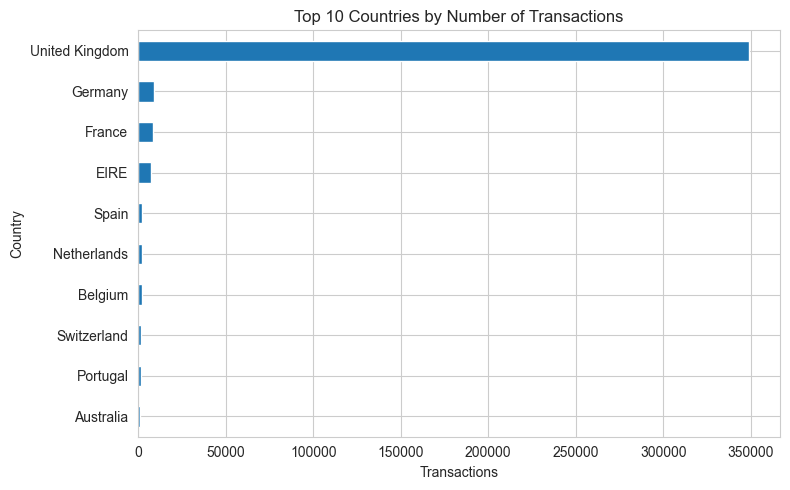

In [6]:
top_countries = df["Country"].value_counts().head(10)
top_countries.plot(kind="barh", title="Top 10 Countries by Number of Transactions")
plt.xlabel("Transactions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


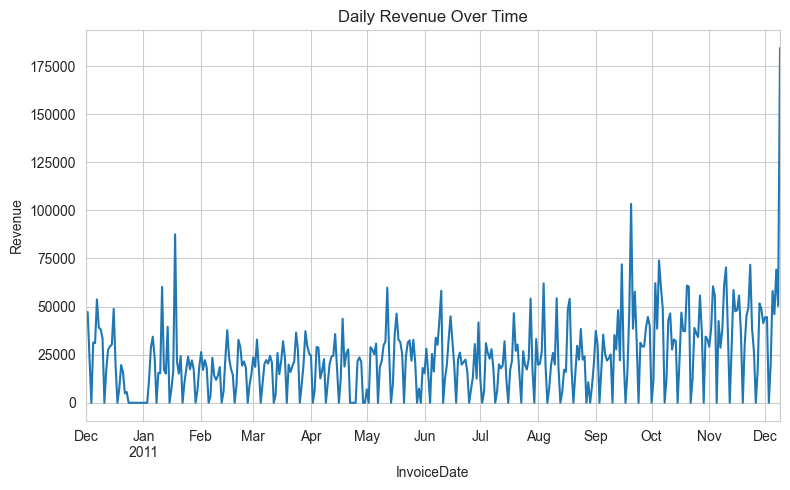

In [7]:
daily_sales = df.set_index("InvoiceDate").resample("D")["TotalPrice"].sum()
daily_sales.plot(title="Daily Revenue Over Time")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


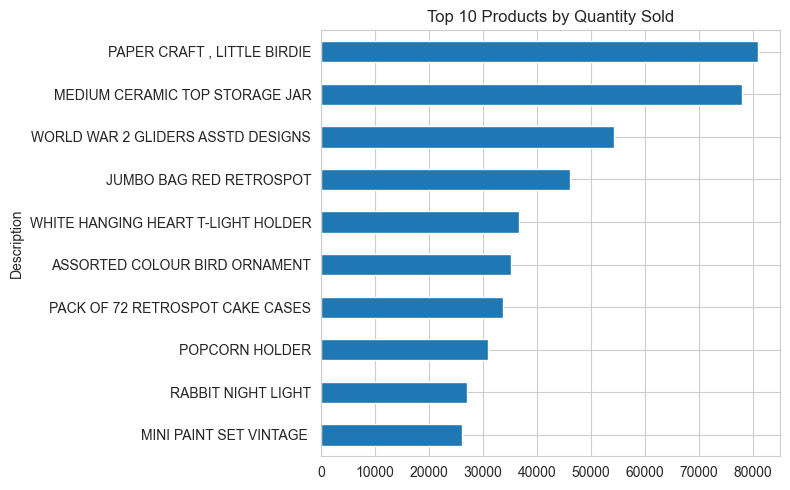

In [8]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh", title="Top 10 Products by Quantity Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. RFM Feature Engineering

For each customer we compute:
- **Recency**: days since their last purchase
- **Frequency**: number of distinct orders
- **Monetary**: total amount spent


In [9]:
rfm = utils.calculate_rfm(df)
print(rfm.shape)
rfm.head()


(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [10]:
rfm.describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


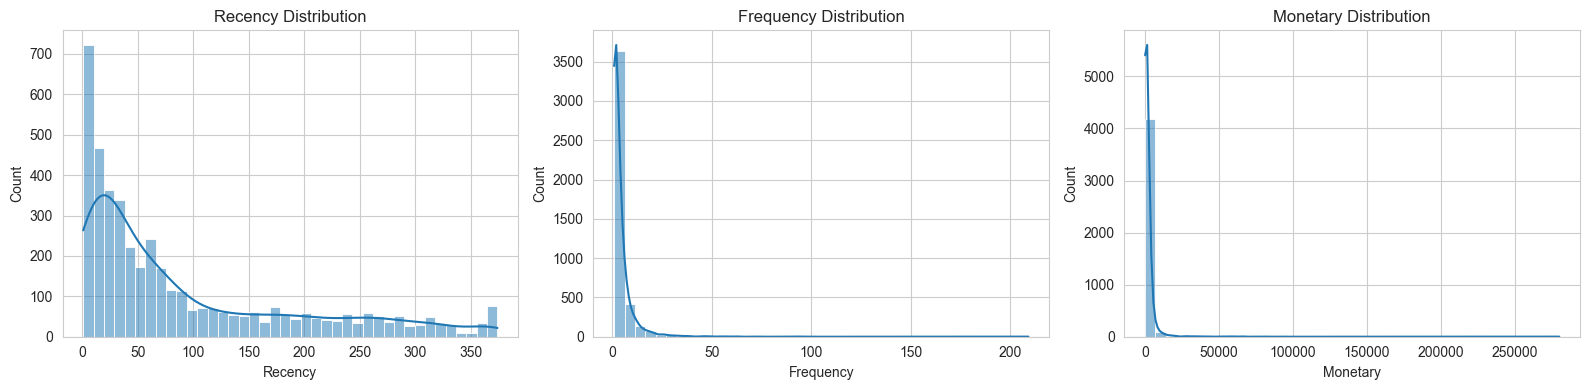

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()


## 5. Log Transform & Scale

RFM features are heavily right-skewed, so we apply `log1p` before standard scaling —
this keeps KMeans (which relies on Euclidean distance) from being dominated by outliers.


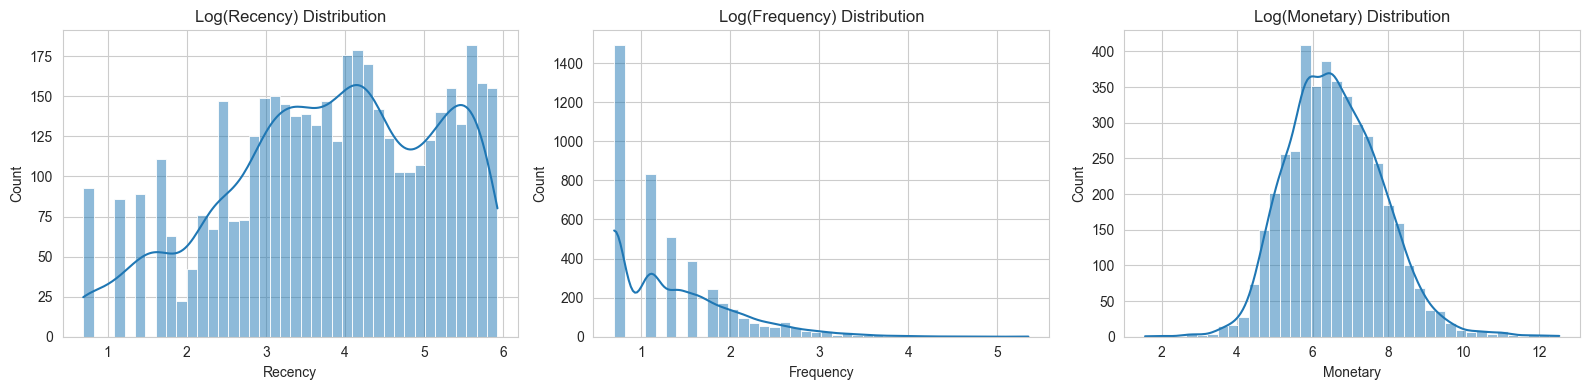

In [12]:
rfm_indexed = rfm.set_index("CustomerID")
log_rfm = utils.log_transform_rfm(rfm_indexed)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(log_rfm[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"Log({col}) Distribution")
plt.tight_layout()
plt.show()


In [13]:
scaled_df, scaler = utils.scale_features(log_rfm, fit=True)
scaled_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.707716
12347,-2.038734,1.074425,1.414903
12348,0.373104,0.386304,0.720024
12349,-0.623086,-0.955214,0.702287
12350,1.424558,-0.955214,-0.614514


## 6. Choosing the Number of Clusters

We use the **elbow method** (inertia) and **silhouette score** to pick a reasonable `k`.


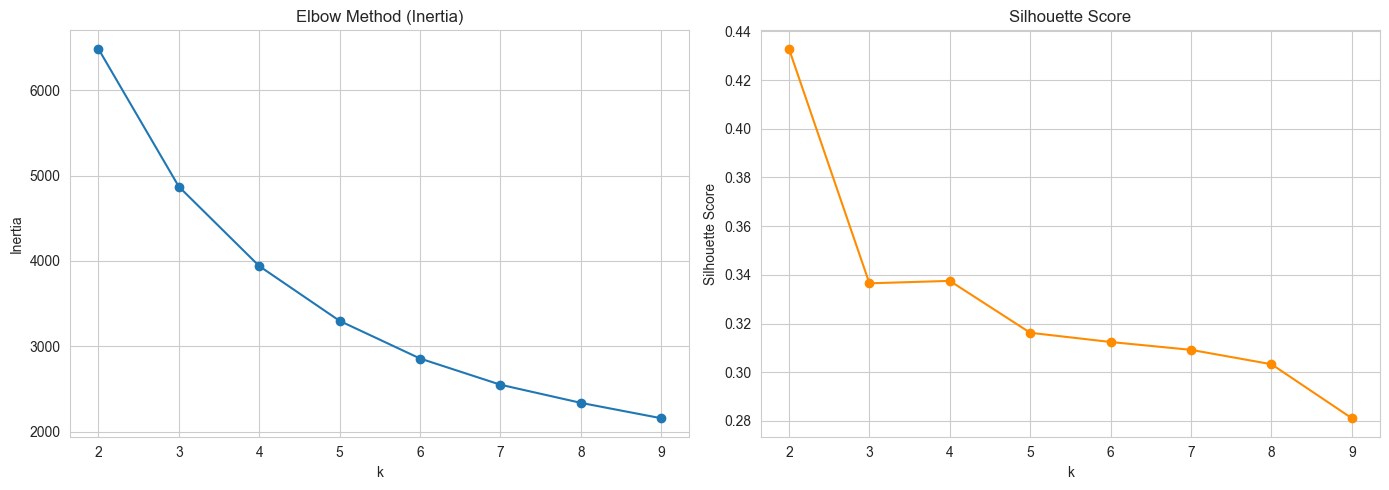

In [14]:
from sklearn.cluster import KMeans

inertias = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_df, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


Based on the elbow point and silhouette score, we proceed with **k = 4** clusters
(adjust `N_CLUSTERS` below if your data suggests a different value).


In [15]:
N_CLUSTERS = 4

kmeans, cluster_labels = utils.train_kmeans(scaled_df, n_clusters=N_CLUSTERS)
rfm_indexed["Cluster"] = cluster_labels
rfm_indexed.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,3
12349,19,1,1757.55,2
12350,310,1,334.40,1


## 7. PCA for Visualization

Explained variance ratio: [0.75078634 0.18786648]


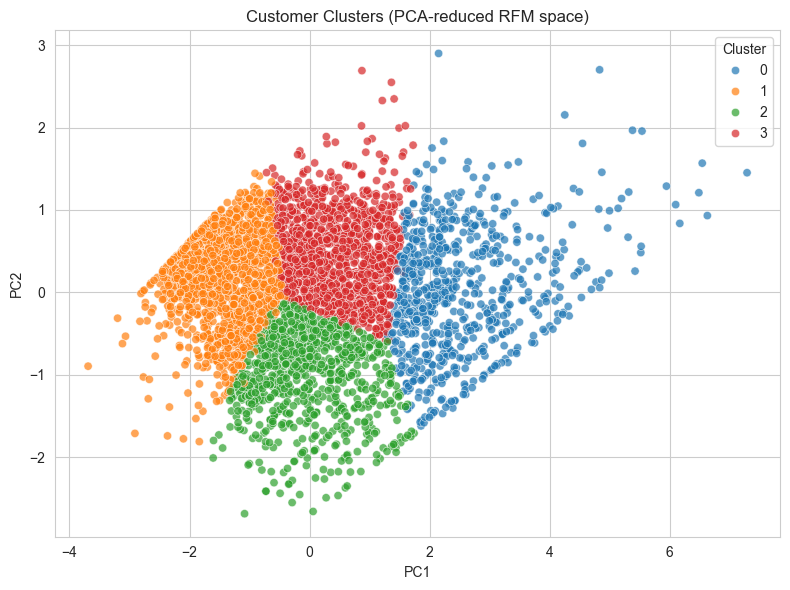

In [16]:
pca_df, pca = utils.apply_pca(scaled_df, fit=True, n_components=2)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plot_df = pca_df.copy()
plot_df["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.7)
plt.title("Customer Clusters (PCA-reduced RFM space)")
plt.tight_layout()
plt.show()


## 8. Profile & Name Segments

We compute the mean Recency/Frequency/Monetary per cluster, then heuristically
assign human-readable segment names (e.g. *Champions*, *At Risk*, *Hibernating*).


In [17]:
cluster_profile = rfm_indexed.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_profile["Count"] = rfm_indexed.groupby("Cluster").size()
cluster_profile


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,12.2,13.8,8088.0,713
1,181.5,1.3,341.0,1622
2,17.7,2.2,557.3,837
3,71.6,4.1,1801.8,1166


In [18]:
cluster_to_segment = utils.label_segments(rfm_indexed, cluster_col="Cluster")
cluster_to_segment


{0: 'Champions',
 3: 'Loyal Customers',
 2: 'Potential Loyalists',
 1: 'At Risk / Need Attention'}

In [19]:
rfm_indexed["Segment"] = rfm_indexed["Cluster"].map(cluster_to_segment)
rfm_indexed["Segment"].value_counts()


Segment
At Risk / Need Attention    1622
Loyal Customers             1166
Potential Loyalists          837
Champions                    713
Name: count, dtype: int64

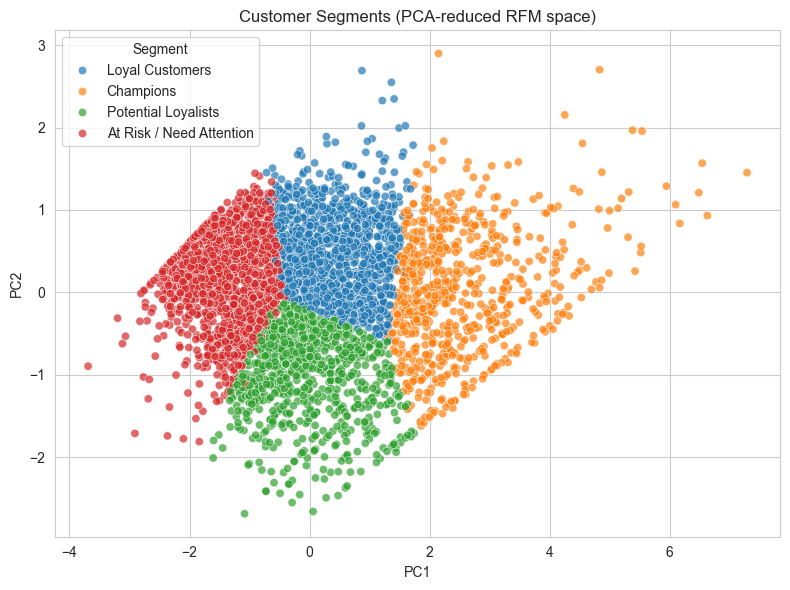

In [20]:
plot_df["Segment"] = plot_df["Cluster"].map(cluster_to_segment)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Segment", palette="tab10", alpha=0.7)
plt.title("Customer Segments (PCA-reduced RFM space)")
plt.tight_layout()
plt.show()


In [21]:
for cluster_id, name in cluster_to_segment.items():
    print(f"Cluster {cluster_id} -> {name}: {utils.SEGMENT_DESCRIPTIONS.get(name, '')}")


Cluster 0 -> Champions: Bought recently, buy often, and spend the most. Reward them, ask for reviews, upsell new products.
Cluster 3 -> Loyal Customers: Buy regularly and respond well to engagement. Upsell higher-value products, ask for referrals.
Cluster 2 -> Potential Loyalists: Recent customers with decent frequency/spend. Offer membership or loyalty programs to build habit.
Cluster 1 -> At Risk / Need Attention: Below-average recency, frequency, and monetary. Reactivate with personalized offers and reminders.


## 9. Save Models

Save the fitted `scaler`, `pca`, and `kmeans` objects so the Streamlit app (`app.py`)
can reuse the exact same preprocessing/clustering pipeline on new data.

We also save the `cluster_to_segment` mapping alongside the KMeans model.


In [22]:
import os

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

utils.save_model(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
utils.save_model(pca, os.path.join(MODELS_DIR, "pca.pkl"))

# Bundle the kmeans model together with its segment-name mapping
kmeans_bundle = {"model": kmeans, "cluster_to_segment": cluster_to_segment}
utils.save_model(kmeans_bundle, os.path.join(MODELS_DIR, "kmeans.pkl"))

print("Saved scaler.pkl, pca.pkl, kmeans.pkl to", MODELS_DIR)


Saved scaler.pkl, pca.pkl, kmeans.pkl to ../models


## 10. Conclusion

The trained pipeline segments customers into actionable groups based on purchase
recency, frequency, and spend. Run `streamlit run app.py` from the project root to
explore the interactive dashboard, score new customers, or upload a fresh transactional
CSV to segment an entire customer base.
